<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Entropy and Information Gain</b>
</h1>

<div style="font-family:'Times New Roman'; font-size:16px;">

<b>Goal:</b>

<ol>
<li>Understand how Decision Trees split data.</li>
<li>Understand Entropy.</li>
<li>Understand Information Gain.</li>
<li>Prepare for building a Decision Tree.</li>
</ol>

</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Why Do We Need Splits?</b>
</h2>

<div style="font-family:'Times New Roman';">

Suppose we want to classify students as <b>Pass</b> or <b>Fail</b>.

A Decision Tree tries to ask questions that separate the classes as much as possible.

<b>Example:</b>

Attendance > 75% ?

Yes → Pass

No → Fail

<b>The question is:</b>

How does the tree decide which question to ask?

</div>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# simple dataset

df = pd.DataFrame({
    "Study_Hours":[1,2,3,4,5,6,7,8],
    "Result":[0,0,0,0,1,1,1,1]
})

df

,Study_Hours,Result
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,1
6,7,1
7,8,1


Result:

0 → Fail

1 → Pass

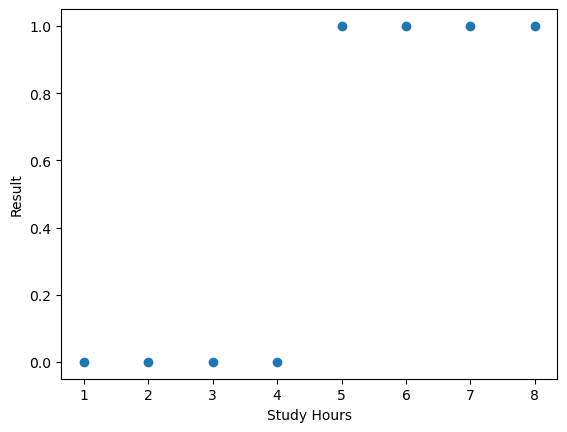

In [4]:
# visualize data

plt.scatter(df["Study_Hours"], df["Result"])

plt.xlabel("Study Hours")
plt.ylabel("Result")

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>What is Entropy?</b>
</h2>

<div style="font-family:'Times New Roman';">

Entropy measures <b>uncertainty</b> or <b>impurity</b> in the data.

<b>High Entropy:</b>
Mixed classes

<b>Low Entropy:</b>
Pure classes

A perfect split tries to reduce entropy as much as possible.

</div>

In [5]:
# entropy function

def entropy(y):

    classes, counts = np.unique(y, return_counts=True)

    probs = counts / len(y)

    ent = -np.sum(probs * np.log2(probs))

    return ent

In [6]:
# entropy of complete dataset

entropy(df["Result"])

np.float64(1.0)

In [7]:
# all same class

entropy([1,1,1,1,1])

np.float64(-0.0)

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Entropy = 0</b>
</h2>

<div style="font-family:'Times New Roman';">

Entropy = 0 means there is <b>no uncertainty</b>.

All samples belong to a single class.

</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Information Gain</b>
</h2>

<div style="font-family:'Times New Roman';">

<b>A split is good if it reduces entropy.</b>

Information Gain tells us how much uncertainty is removed after splitting the data.

</div>

In [8]:
# split dataset

left = df[df["Study_Hours"] <= 4]["Result"]

right = df[df["Study_Hours"] > 4]["Result"]

In [9]:
print("Left Entropy :", entropy(left))
print("Right Entropy :", entropy(right))

Left Entropy : -0.0
Right Entropy : -0.0


In [10]:
# information gain calculation

parent_entropy = entropy(df["Result"])

left_entropy = entropy(left)
right_entropy = entropy(right)

weighted_entropy = (
    len(left)/len(df) * left_entropy
    +
    len(right)/len(df) * right_entropy
)

information_gain = parent_entropy - weighted_entropy

print("Information Gain :", information_gain)

Information Gain : 1.0


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Perfect Split</b>
</h2>

<div style="font-family:'Times New Roman';">

This is a <b>perfect split</b>.

<b>Before Split:</b> Entropy = 1

<b>After Split:</b> Entropy = 0

<b>Information Gain:</b>

Information Gain = 1

The split completely separates the classes, resulting in zero uncertainty.

</div>

In [11]:
# bad split

left = df[df["Study_Hours"] <= 2]["Result"]

right = df[df["Study_Hours"] > 2]["Result"]

In [12]:
parent_entropy = entropy(df["Result"])

left_entropy = entropy(left)
right_entropy = entropy(right)

weighted_entropy = (
    len(left)/len(df)*left_entropy
    +
    len(right)/len(df)*right_entropy
)

ig = parent_entropy - weighted_entropy

print("Information Gain :", round(ig,4))

Information Gain : 0.3113


<h3 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Observation</b>
</h3>

<div style="font-family:'Times New Roman'; font-size:16px;">

<b>Higher Information Gain</b>

→ Better Split

<b>Lower Information Gain</b>

→ Worse Split

A Decision Tree always chooses the split with the highest Information Gain because it reduces uncertainty the most.

</div>

<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Conclusion</b>
</h1>

<div style="font-family:'Times New Roman'; font-size:16px;">

<ul>
<li>Decision Trees learn using rules.</li>
<li>Entropy measures uncertainty.</li>
<li>Entropy = 0 means pure data.</li>
<li>Information Gain measures reduction in uncertainty.</li>
<li>A good split reduces entropy.</li>
<li>Decision Trees choose the split with the highest Information Gain.</li>
</ul>

<b>Decision Tree Workflow:</b>

Calculate Entropy <br>
↓ <br>
Try Splits <br>
↓ <br>
Compute Information Gain <br>
↓ <br>
Choose Best Split <br>
↓ <br>
Repeat

</div>